# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
#file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
# from sweep import sweep_load as sl
# from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.image as mpimg

from matplotlib.gridspec import GridSpec

import sys
#sys.path.append("../utils")
#from utils import *

import matplotlib.patches as patches
import os

In [3]:
update_rc_params('talk')

# Individual Panels

## a: Optical image of finished device

In [4]:
from PIL import Image
from ipywidgets import interact, FloatSlider, IntSlider

# Load image
img0 = Image.open("../data/ed-fig-optical/final13.jpg")

img_np = np.array(img0)


def show(angle, x0, y0, w, h):
    # rotate
    img_rot = img0.rotate(angle, expand=True)
    img_rot_np = np.array(img_rot)

    # crop (make sure bounds are valid)
    x1 = int(x0)
    y1 = int(y0)
    x2 = int(x0 + w)
    y2 = int(y0 + h)

    x1 = max(0, min(x1, img_rot_np.shape[1]-1))
    x2 = max(1, min(x2, img_rot_np.shape[1]))
    y1 = max(0, min(y1, img_rot_np.shape[0]-1))
    y2 = max(1, min(y2, img_rot_np.shape[0]))

    cropped = img_rot_np[y1:y2, x1:x2]

    plt.figure(figsize=(6,6))
    plt.imshow(cropped)
    plt.axis("off")
    plt.show()


# Sliders
interact(
    show,
    angle=FloatSlider(min=0, max=60, step=1, value=0),
    x0=IntSlider(min=0, max=2000, step=1, value=0),
    y0=IntSlider(min=0, max=2000, step=1, value=0),
    w=IntSlider(min=10, max=5000, step=10, value=500),
    h=IntSlider(min=10, max=5000, step=10, value=500),
)

interactive(children=(FloatSlider(value=0.0, description='angle', max=60.0, step=1.0), IntSlider(value=0, desc…

<function __main__.show(angle, x0, y0, w, h)>

In [5]:
angle = 39   # example
x0, y0 = 1306, 1505
w, h = 860, 490

img_rot = img0.rotate(angle, expand=True)
img_rot_np = np.array(img_rot)

cropped = img_rot_np[y0:y0+h, x0:x0+w]

Image.fromarray(cropped).save("final13_processed.png")

## b: AFM image of finished device

In [6]:
# !pip3 install pspylib

In [7]:
# pspylib (lab AFM .tiff reader) is required for this panel; obtain it separately.

import pspylib as ps

In [8]:
def level_by_mean_plane(img):
    """
    Fits a 2D mean plane to the image and subtracts it, 
    replicating Gwyddion's 'Level data by mean plane' function.
    """
    # 1. Get image dimensions
    rows, cols = img.shape
    
    # 2. Create X and Y coordinate grids
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    
    # 3. Flatten the grids and the image for the least squares solver
    X_flat = X.flatten()
    Y_flat = Y.flatten()
    Z_flat = img.flatten()
    
    # 4. Construct the design matrix: [X, Y, 1]
    A = np.c_[X_flat, Y_flat, np.ones_like(X_flat)]
    
    # 5. Solve for the plane coefficients (a*x + b*y + c) using least squares
    coefficients, _, _, _ = np.linalg.lstsq(A, Z_flat, rcond=None)
    
    # 6. Reconstruct the 2D plane
    plane = coefficients[0] * X + coefficients[1] * Y + coefficients[2]
    
    # 7. Subtract the plane from the original image
    return img - plane

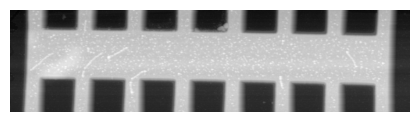

In [9]:
update_rc_params('paper')  # paper style for this final figure

folder = "../data/ed-fig-optical/AFM_scans"
sample = "SF96K1"
channel = "Z Height"
direction = "Forward"

fname = os.path.join(
    folder,
    f"{sample}_10_{channel}_{direction}.tiff"
)

a = ps.TiffReader(fname)
h = a.data.scanHeader.scanHeader

img = a.data.scanData.ZData
img_h = img.reshape((h['height'][0], h['width'][0]))
img_h = level_by_mean_plane(img_h)

N = h['scanSizeWidth'][0]    # μm
M = h['scanSizeHeight'][0]   # μm

# Figure aspect matches physical aspect ratio
fig_w = 4
fig_h = fig_w * (M / N)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.imshow(
    img_h,
    origin='lower',
    extent=[0, N, 0, M],
    cmap='gray'
)

# Remove everything
ax.set_axis_off()

# Fill entire canvas
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.show()

# fig.savefig("afm-height-v2.png", dpi=600, bbox_inches='tight',pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default

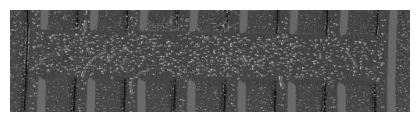

In [10]:
update_rc_params('paper')  # paper style for this final figure

folder = "../data/ed-fig-optical/AFM_scans"
sample = "SF96K1"
channel = "NCM Phase"
direction = "Forward"

fname = os.path.join(
    folder,
    f"{sample}_10_{channel}_{direction}.tiff"
)

a = ps.TiffReader(fname)
h = a.data.scanHeader.scanHeader

img = a.data.scanData.ZData
img_p = img.reshape((h['height'][0], h['width'][0]))
img_p = level_by_mean_plane(img_p)

N = h['scanSizeWidth'][0]    # μm
M = h['scanSizeHeight'][0]   # μm

# Figure aspect matches physical aspect ratio
fig_w = 4
fig_h = fig_w * (M / N)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.imshow(
    img_p,
    origin='lower',
    extent=[0, N, 0, M],
    cmap='gray'
)

# Remove everything
ax.set_axis_off()

# Fill entire canvas
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.show()

# fig.savefig("afm-phase-v2.png", dpi=600, bbox_inches='tight',pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default

## c: Contact schematic

# Full figure

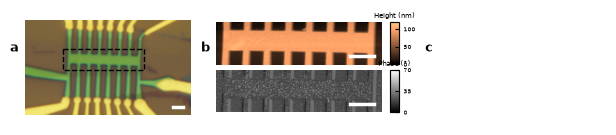

In [11]:
update_rc_params('paper')  # paper style for this final figure

fig = plt.figure(figsize=(7.5, 1.5))
gs = GridSpec(1, 5, figure=fig,   
              width_ratios=[1, 0.15, 1, 0.35, 1], # 0.1 is the first gap, 0.35 is the second gap
              height_ratios=[1],
              hspace=1., 
              wspace=0.0)


################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
ax.axis("off")

img = mpimg.imread("final13_processed.png") 
ax.imshow(img)

ax.autoscale(False)

# --- Add the black dashed box ---
# (x, y) is the top-left corner of the box. 
# Adjust these numbers to place it exactly where you want it on your image.
box_x = 195      
box_y = 150      
box_width = 420  
box_height = box_width*3/11.75

rect = patches.Rectangle((box_x, box_y), box_width, box_height, 
                         linewidth=1., edgecolor='black', facecolor='none', linestyle='--', zorder=1000)


# plt.show()

ax.add_patch(rect)
# 1. Get the exact dimensions of the Panel a image
img_height, img_width = img.shape[:2]

# 2. Define how long the scale bar should be (in pixels)
# (Adjust this to represent your actual physical scale, e.g., 200 pixels = 1um)
bar_length = 70/46*35

# 3. Position it dynamically (e.g., 40 pixels from the bottom and right edges)
padding_x = 40
padding_y = 40

x_end = img_width - padding_x
x_start = x_end - bar_length
y_pos = img_height - padding_y


# 4. Plot the scale bar
ax.plot([x_start, x_end], [y_pos, y_pos], ls="-", color="white", lw=2.5, zorder=100)

pos = ax.get_position()
# print(pos)
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, 0.6, "a", fontweight='bold')


from mpl_toolkits.axes_grid1 import make_axes_locatable # Add this import!

################ Panel b ##################
outer = gs[0, 2].subgridspec(2, 1, hspace=0.1)

ax1 = fig.add_subplot(outer[0, 0])
ax2 = fig.add_subplot(outer[1, 0])

img1, img2 = img_h.copy(), img_p.copy()
img1 -= img1.min()
img1 *= 1e3
img2 -= img2.min()


# 1. Plot the images and save the outputs to variables (im1, im2)
im1 = ax1.imshow(img1, cmap='copper', origin='lower', extent=[0, N, 0, M], vmin=0, vmax=120)
im2 = ax2.imshow(img2, cmap='gray', origin='lower', extent=[0, N, 0, M], vmin=0, vmax=70)

ax1.set_anchor('S') 
ax2.set_anchor('N') 

# Calculate dynamic scale bar positions based on your extent
bar_length = N * 0.145    
x_end = N * 0.95       
x_start = x_end - bar_length
y_base = M * 0.2

# Apply formatting and scale bars perfectly equally
for ax in [ax1, ax2]:
    ax.axis("off")
    ax.set_aspect('equal')
    ax.autoscale(False)
    ax.plot([x_start, x_end], [y_base, y_base], ls="-", color="white", lw=2.5, zorder=100)

# 2. Add the vertical colorbars with horizontal labels at the top
cbar_labels = ["Height (nm)", "Phase (°)"]

cbar_ticks = [[0, 50, 100], [0, 35, 70]]

# Add the ticks to the zip loop!
for ax, im, label, ticks in zip([ax1, ax2], [im1, im2], cbar_labels, cbar_ticks):
    
    cax = ax.inset_axes([1.05, 0.0, 0.05, 1.0])
    cbar = fig.colorbar(im, cax=cax)
    
    cbar.ax.set_title(label, fontsize=5, pad=3)
    
    # --- Set the Ticks ---
    cbar.set_ticks(ticks)
    
    cbar.ax.tick_params(labelsize=4) 

# Add the panel letter
pos = ax1.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, 0.6, "b", fontweight='bold')


################ Panel c ##################
ax = fig.add_subplot(gs[0, 4])
fig.canvas.draw()  
ax.axis("off")


pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, 0.6, "c", fontweight='bold')

plt.show()
#fig.savefig("ed-fig-optical.pdf", dpi=600, bbox_inches='tight',pad_inches=0.02, transparent=False)
plt.rcParams['svg.fonttype'] = 'none'  # keep text as text, not paths

fig.savefig("ed-fig-optical.svg", bbox_inches='tight',
            pad_inches=0.02, transparent=True)

update_rc_params('talk')  # restore presentation default